<a href="https://colab.research.google.com/github/khanuja74/khanuja74/blob/main/Electric_Vehicle_Sales_Analysis_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Data Loaded Successfully!

Shape of dataset: (96845, 8)

Preview:
   Year Month_Name      Date           State         Vehicle_Class  \
0  2014        jan  1/1/2014  Andhra Pradesh       ADAPTED VEHICLE   
1  2014        jan  1/1/2014  Andhra Pradesh  AGRICULTURAL TRACTOR   
2  2014        jan  1/1/2014  Andhra Pradesh             AMBULANCE   
3  2014        jan  1/1/2014  Andhra Pradesh   ARTICULATED VEHICLE   
4  2014        jan  1/1/2014  Andhra Pradesh                   BUS   

  Vehicle_Category Vehicle_Type  EV_Sales_Quantity  
0           Others       Others                  2  
1           Others       Others                  6  
2           Others       Others                  9  
3           Others       Others                  2  
4              Bus          Bus                 33  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------     

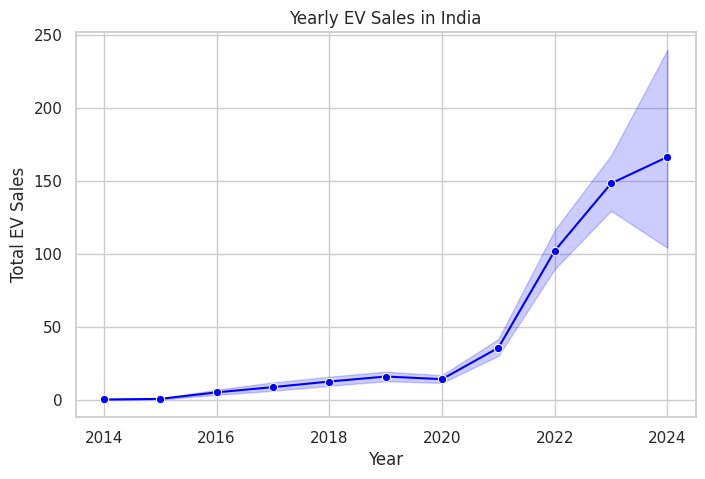

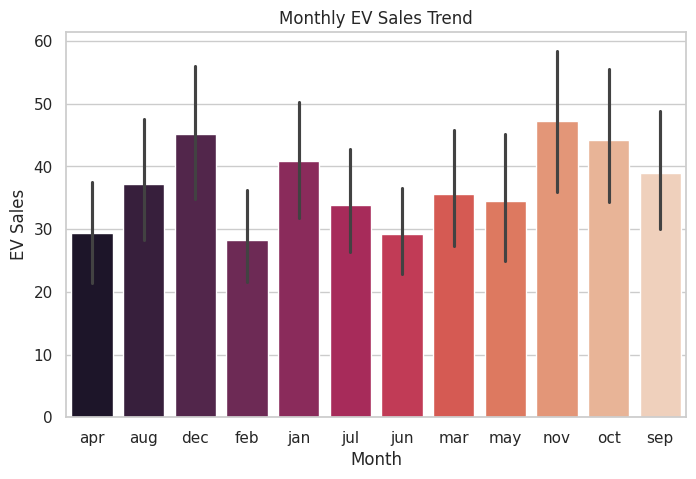

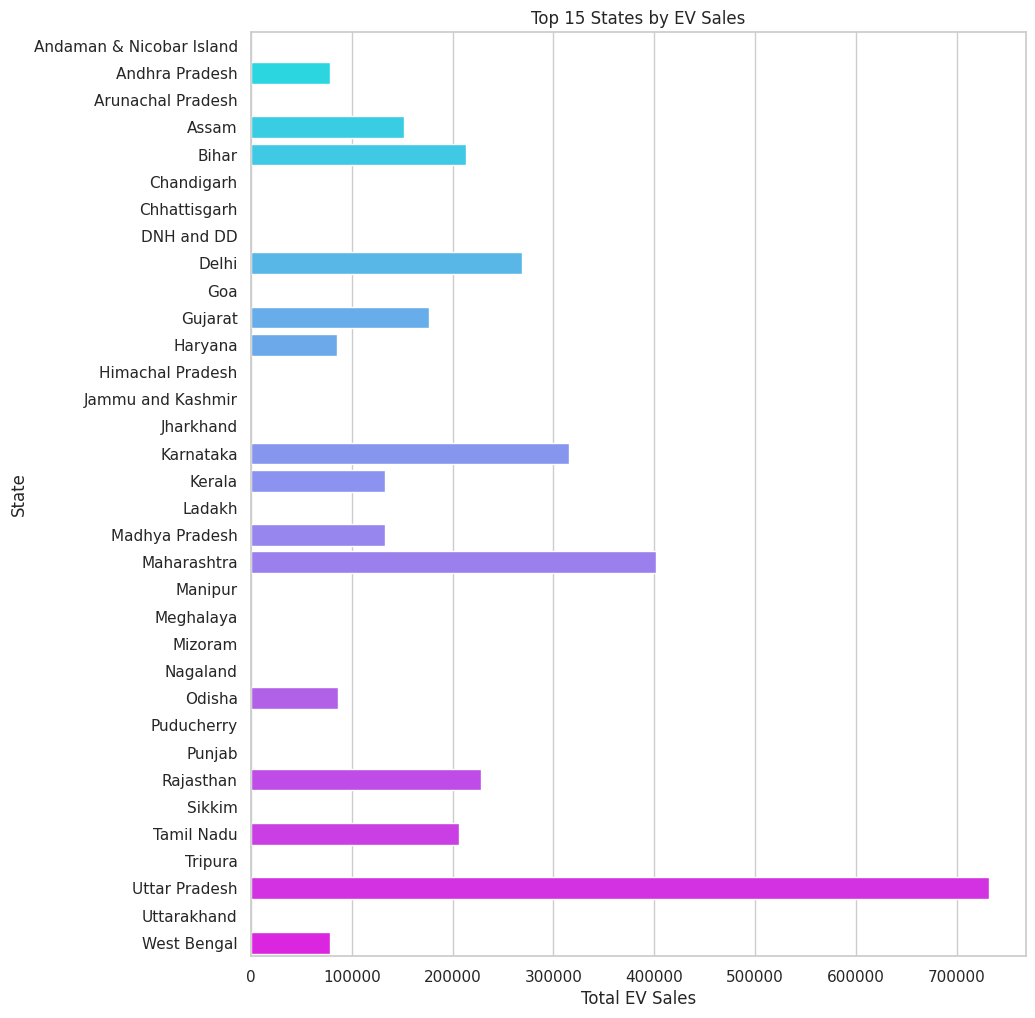

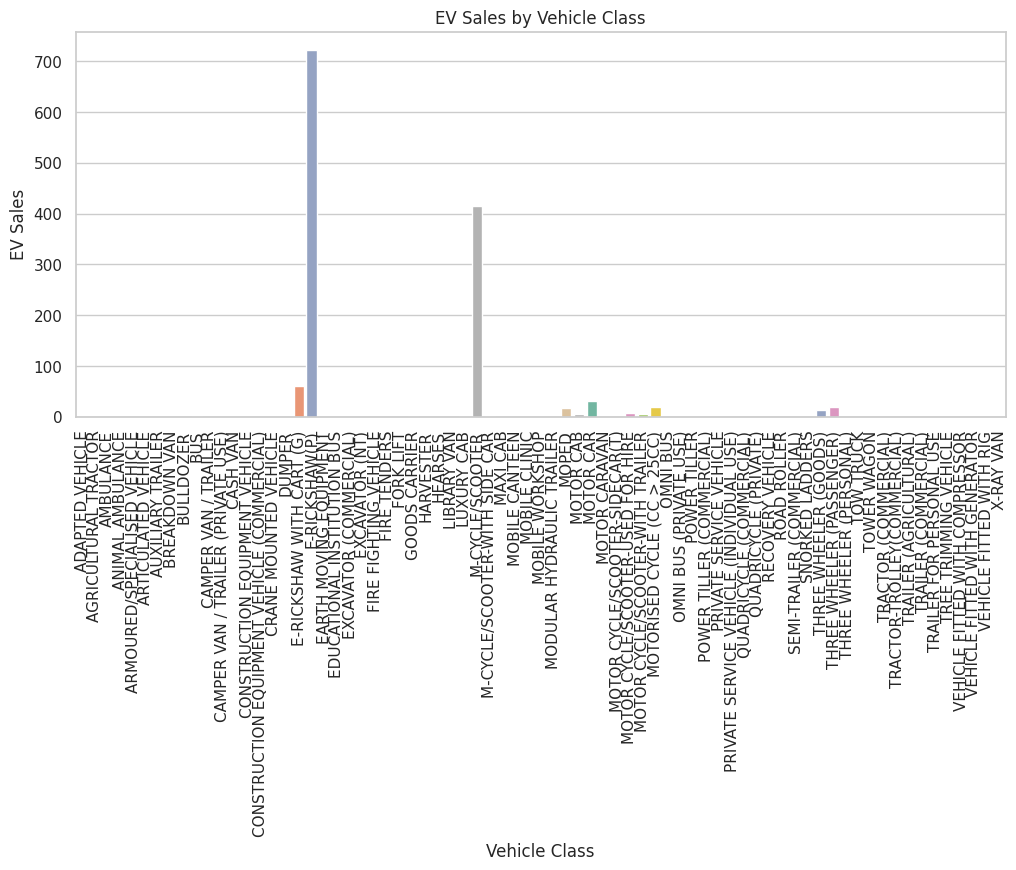

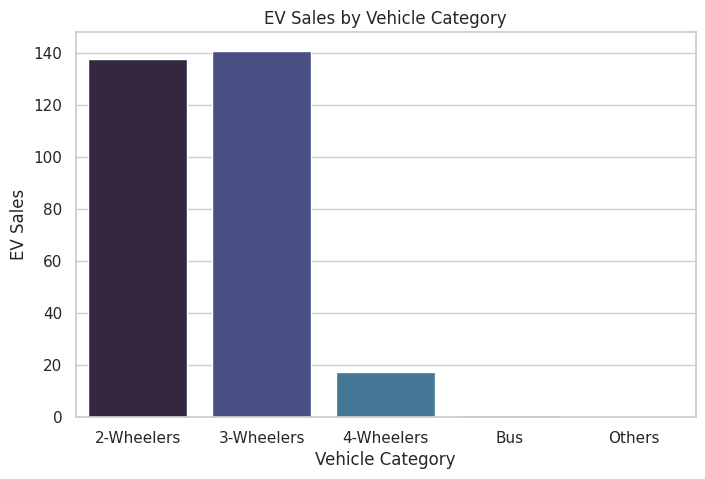

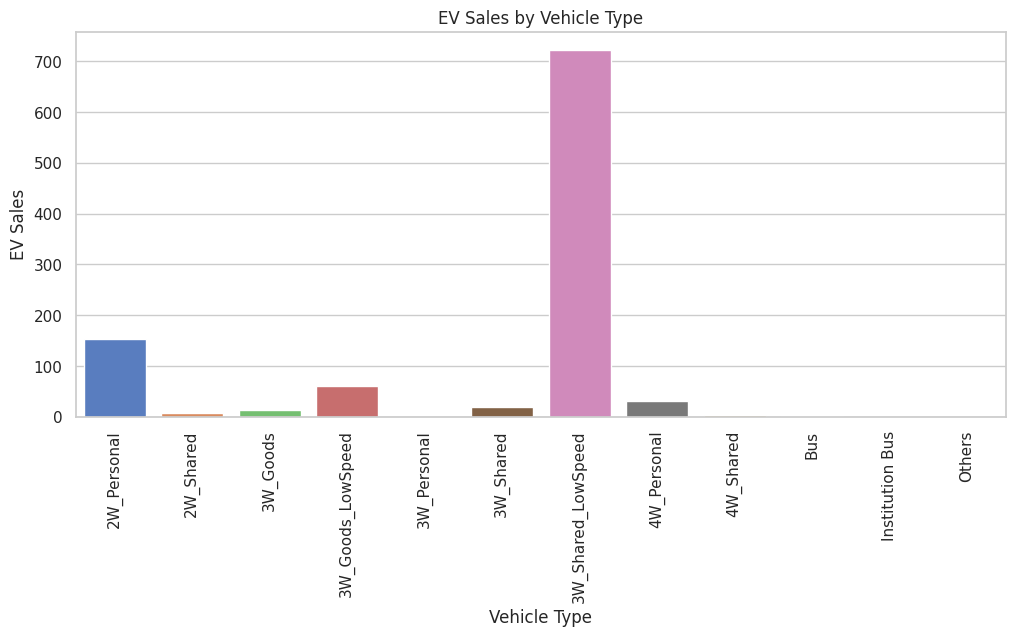


📊 INSIGHTS:
1️⃣ Total Records: 96845
2️⃣ Time Range: 2014 to 2024
3️⃣ Highest Selling State: Uttar Pradesh
4️⃣ Highest Vehicle Category: Others
5️⃣ Average EV Sales Quantity: 37.13

💾 Cleaned dataset saved as 'Cleaned_EV_Sales_Data.csv'


In [2]:
# ⚡ ELECTRIC VEHICLE SALES BY STATE IN INDIA — DATA ANALYSIS PROJECT

# 1️⃣ Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# 2️⃣ Load Dataset
df = pd.read_csv("Electric-Vehicle-Sales-by-State-in-India.csv", engine='python', on_bad_lines='skip', encoding_errors='ignore')
print("✅ Data Loaded Successfully!\n")
print("Shape of dataset:", df.shape)
print("\nPreview:")
print(df.head())

# 3️⃣ Data Overview
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# 4️⃣ Data Cleaning
df['Year'] = df['Year'].astype(int)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
categorical_cols = ['Month_Name', 'State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type']
df[categorical_cols] = df[categorical_cols].astype('category')

print("\n✅ Cleaned Data Info:")
print(df.info())

# 5️⃣ Basic Statistics
print("\nDescriptive Statistics:")
print(df.describe())

# 6️⃣ Data Analysis & Visualization

# (a) Yearly Trend of EV Sales
plt.figure(figsize=(8,5))
sns.lineplot(x='Year', y='EV_Sales_Quantity', data=df, marker='o', color='blue')
plt.title("Yearly EV Sales in India")
plt.xlabel("Year")
plt.ylabel("Total EV Sales")
plt.show()

# (b) Monthly EV Sales Trend
plt.figure(figsize=(8,5))
sns.barplot(x='Month_Name', y='EV_Sales_Quantity', data=df, palette='rocket')
plt.title("Monthly EV Sales Trend")
plt.xlabel("Month")
plt.ylabel("EV Sales")
plt.show()

# (c) State-wise EV Sales
plt.figure(figsize=(10,12))
top_states = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=top_states.values, y=top_states.index, palette='cool')
plt.title("Top 15 States by EV Sales")
plt.xlabel("Total EV Sales")
plt.ylabel("State")
plt.show()

# (d) EV Sales by Vehicle Class
plt.figure(figsize=(12,5))
sns.barplot(x='Vehicle_Class', y='EV_Sales_Quantity', data=df, palette='Set2', ci=None)
plt.title("EV Sales by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("EV Sales")
plt.xticks(rotation=90)
plt.show()

# (e) EV Sales by Vehicle Category
plt.figure(figsize=(8,5))
sns.barplot(x='Vehicle_Category', y='EV_Sales_Quantity', data=df, palette='mako', ci=None)
plt.title("EV Sales by Vehicle Category")
plt.xlabel("Vehicle Category")
plt.ylabel("EV Sales")
plt.show()

# (f) EV Sales by Vehicle Type
plt.figure(figsize=(12,5))
sns.barplot(x='Vehicle_Type', y='EV_Sales_Quantity', data=df, palette='muted', ci=None)
plt.title("EV Sales by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("EV Sales")
plt.xticks(rotation=90)
plt.show()

# 7️⃣ Key Insights
print("\n📊 INSIGHTS:")
print(f"1️⃣ Total Records: {len(df)}")
print(f"2️⃣ Time Range: {df['Year'].min()} to {df['Year'].max()}")
print(f"3️⃣ Highest Selling State: {top_states.index[0]}")
print(f"4️⃣ Highest Vehicle Category: {df['Vehicle_Category'].value_counts().idxmax()}")
print(f"5️⃣ Average EV Sales Quantity: {df['EV_Sales_Quantity'].mean():.2f}")

# 8️⃣ Save Cleaned Dataset
df.to_csv("Cleaned_EV_Sales_Data.csv", index=False)
print("\n💾 Cleaned dataset saved as 'Cleaned_EV_Sales_Data.csv'")